c:\Users\Louis\Documents\Master MLSD\M1\Examen final technique de contenerisation\Examen_Technologies_Conteneurisation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Explained variance ratio: [0.53805804 0.25833116 0.07327942 0.05452794 0.03630705 0.02475203]
Total variance retained: 0.9852556463427027


c:\Users\Louis\Documents\Master MLSD\M1\Examen final technique de contenerisation\Examen_Technologies_Conteneurisation\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


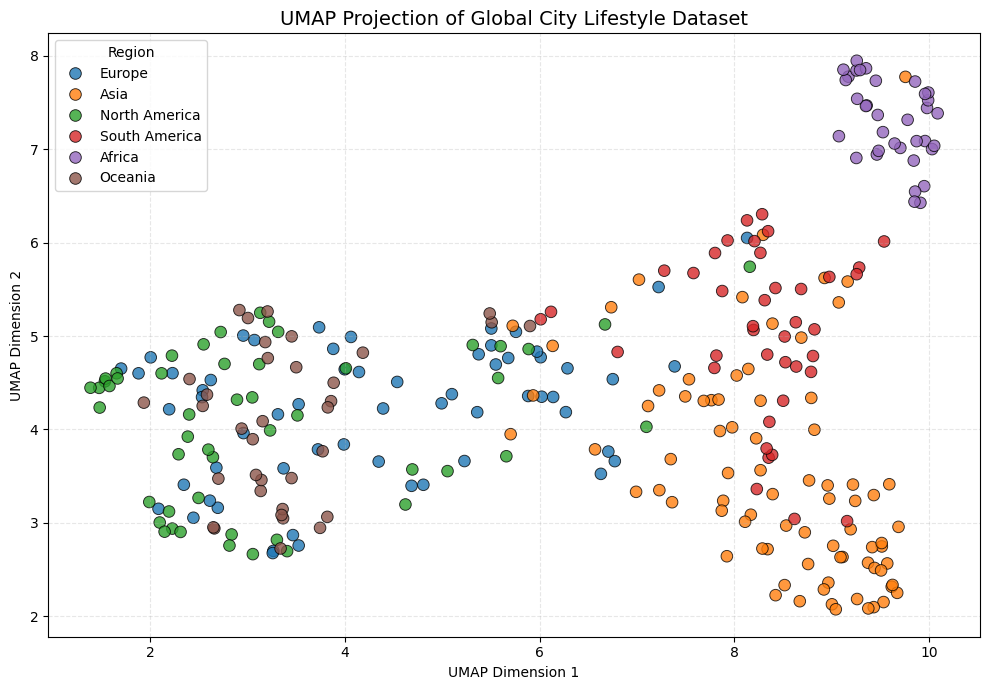

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap.umap_ as umap


df = pd.read_csv("../data/city_lifestyle_dataset.csv")


numeric_cols = [
    "population_density",
    "avg_income",
    "internet_penetration",
    "avg_rent",
    "air_quality_index",
    "public_transport_score",
    "happiness_score",
    "green_space_ratio"
]

X = df[numeric_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", np.sum(pca.explained_variance_ratio_))


umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)

embedding = umap_model.fit_transform(X_pca)

df["UMAP1"] = embedding[:, 0]
df["UMAP2"] = embedding[:, 1]

output_df = df[["UMAP1", "UMAP2"]]

# Export to CSV
output_df.to_csv("../outputs/umap_emb_2d.csv", index=False)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="UMAP1",
    y="UMAP2",
    hue="country",
    palette="tab10",
    s=70,
    alpha=0.8,
    edgecolor="black"
)

plt.title("UMAP Projection of Global City Lifestyle Dataset", fontsize=14)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Region")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Observation du résultat

Au travers du graph nous pouvons voir plusieurs groupes distincts de villes. On distingue notamment une séparation nette des villes africaines (en violet), ce qui suggère un profil de style de vie relativement homogène et distinct des autres régions. Les villes asiatiques (en orange) semblent quant à elles se disperser davantage, notamment vers le bas du graphique, traduisant une plus grande hétérogénéité interne. Les villes européennes, nord-américaines et sud-américaines apparaissent plus mélangées dans la zone centrale, ce qui pourrait indiquer des similarités de profil entre ces régions. Dans l'ensemble, la réduction dimensionnelle semble donc capturer des tendances régionales cohérentes, même si certains chevauchements restent présents.
